<a href="https://colab.research.google.com/github/sophiezydfifi/207fall-project-ding-peteh-valadez-zhang/blob/main/DSCI266_Semantic_Entropy_Result_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATASCI 266 Final Project Model Results Analysis

## Evaluating Semantic Entropy for Hallucination Detection in Recent Large Language Models
**Section:** 5

**Team Members:** Kim Chen, Sophie Ding, Jacob Schorr

### Semantic Entropy Formula

$$H_{SE} = -\sum_{c \in C} p(c \mid x) \log p(c \mid x)$$

### Analysis Environment Setup

In [1]:
!pip install torch scikit-learn -q
!pip install transformers accelerate datasets -q
!pip install sentencepiece protobuf tqdm -q

In [2]:
import json
import math
import statistics as st
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from google.colab import drive


### Load the Five JSON Files

In [3]:
drive.mount("/content/drive")
DRIVE_DIR = Path("/content/drive/MyDrive/266/Project Result_v2/") # updated 3/29 with new results

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
FILE_MAP = {
    "Llama-2-7B-Chat (base)": "llama_2_7b_chat_hf_trivia_qa.json",
    "Llama-3.1-8B": "llama_3.1_8b_trivia_qa.json",
    "Llama-3.1-8B-Instruct": "llama_3.1_8b_instruct_trivia_qa.json",
    "Gemma-3-12B-PT": "gemma_3_12b_pt_trivia_qa.json",
    "Gemma-3-12B-IT": "gemma_3_12b_it_trivia_qa.json",
}
rows = {}
for label, fn in FILE_MAP.items():
    path = DRIVE_DIR / fn
    with open(path, "r", encoding="utf-8") as f:
        rows[label] = json.load(f)
names = list(FILE_MAP.keys())
base_name, base = names[0], rows[names[0]]
n = len(base)
for name in names[1:]:
    d = rows[name]
    assert len(d) == n
    assert sum(1 for a, b in zip(base, d) if a["sample_id"] != b["sample_id"]) == 0

### Data Sanity Check

In [5]:
# Each JSON file must be a list of this many evaluation rows (one row = one question tried).
EXPECTED_RECORDS = 400

names = list(FILE_MAP.keys())
base_name = names[0]
base = rows[base_name]

print(
    f"=== Per-file record count (expect {EXPECTED_RECORDS} questions per file) ==="
)
for name in names:
    d = rows[name]
    n_here = len(d)
    if n_here == EXPECTED_RECORDS:
        print(f"  {name}: {n_here} records — OK")
    else:
        print(f"  {name}: {n_here} records — FAIL (expected {EXPECTED_RECORDS})")
    assert n_here == EXPECTED_RECORDS, (
        f"{name}: expected {EXPECTED_RECORDS} records (questions tried), got {n_here}"
    )

n = len(base)

for name in names[1:]:
    d = rows[name]
    assert len(d) == n, f"{name}: length {len(d)} != base {n}"
    mism = sum(1 for a, b in zip(base, d) if a["sample_id"] != b["sample_id"])
    assert mism == 0, f"{name}: {mism} rows misaligned vs base"

sid_counts = Counter(r["sample_id"] for r in base)
dup_ids = [k for k, v in sid_counts.items() if v > 1]
n_unique = len(sid_counts)
print(f"\nAll files aligned: {n} rows, same sample_id order row-by-row.")
print(
    f"Distinct sample_id across base file: {n_unique} (can be < {n} if some ids repeat)."
)
if dup_ids:
    print(f"Repeated sample_id: {dup_ids}")
else:
    print("No repeated sample_id.")
print("Sanity checks passed.")

=== Per-file record count (expect 400 questions per file) ===
  Llama-2-7B-Chat (base): 400 records — OK
  Llama-3.1-8B: 400 records — OK
  Llama-3.1-8B-Instruct: 400 records — OK
  Gemma-3-12B-PT: 400 records — OK
  Gemma-3-12B-IT: 400 records — OK

All files aligned: 400 rows, same sample_id order row-by-row.
Distinct sample_id across base file: 400 (can be < 400 if some ids repeat).
No repeated sample_id.
Sanity checks passed.


### Analysis

In [7]:
def accuracy(data): # Fraction of questions where the evaluated answer matches gold (your pipeline’s correctness flag).
    return sum(1 for r in data if r["is_correct"]) / len(data)

def mean_se_correct(data): # Average se_score over rows with is_correct == True.
    """Mean se_score restricted to rows where the model answer is correct."""
    xs = [r["se_score"] for r in data if r["is_correct"]]
    return st.mean(xs) if xs else float("nan")


def mean_se_incorrect(data): # Average se_score over rows with is_correct == False.
    """Mean se_score restricted to incorrect rows (hallucination / wrong-fact proxy)."""
    xs = [r["se_score"] for r in data if not r["is_correct"]]
    return st.mean(xs) if xs else float("nan")


def se_separation_ratio(data): #
    """mean(SE | incorrect) / mean(SE | correct). >1 => higher SE on errors (Farquhar-style separation)."""
    mc = mean_se_correct(data)
    mi = mean_se_incorrect(data)
    if math.isnan(mc) or math.isnan(mi):
        return float("nan")
    if math.isclose(mc, 0.0, abs_tol=1e-12):
        return float("inf") if mi > 0 else float("nan")
    return mi / mc


def se_separation_ratio(data):
    """mean(SE | incorrect) / mean(SE | correct). >1 => higher SE on errors (Farquhar-style separation)."""
    mc = mean_se_correct(data)
    mi = mean_se_incorrect(data)
    if math.isnan(mc) or math.isnan(mi):
        return float("nan")
    if math.isclose(mc, 0.0, abs_tol=1e-12):
        return float("inf") if mi > 0 else float("nan")
    return mi / mc


def mean_avg_logprob(data):
    vals = []
    for r in data:
        lp = r.get("length_norm_logprobs") or []
        if lp:
            vals.append(st.mean(lp))
    return st.mean(vals) if vals else float("nan")


def pearson(xs, ys):
    """Pearson r; with ys in {0,1} this matches point-biserial correlation (SE vs correctness)."""
    nloc = len(xs)
    mx, my = st.mean(xs), st.mean(ys)
    vx = st.pvariance(xs) ** 0.5
    vy = st.pvariance(ys) ** 0.5
    if vx == 0 or vy == 0:
        return float("nan")
    cov = sum((x - mx) * (y - my) for x, y in zip(xs, ys)) / nloc
    return cov / (vx * vy)


def chi2_sf_1df(x):
    """Upper tail P(χ²₁ > x); used as McNemar p-value (no scipy)."""
    if x <= 0:
        return 1.0
    return 2 * (1 - 0.5 * (1 + math.erf(math.sqrt(x / 2))))


def mcnemar_paired(b, o):
    """Paired binary correctness: discordant counts n01 (base wrong, o right) vs n10; continuity-corrected χ²."""
    n01 = sum(1 for x, y in zip(b, o) if (not x["is_correct"]) and y["is_correct"])
    n10 = sum(1 for x, y in zip(b, o) if x["is_correct"] and (not y["is_correct"]))
    if n01 + n10 == 0:
        return 1.0, n01, n10
    chi = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)  # continuity correction
    p = chi2_sf_1df(chi)
    return p, n01, n10


def cluster_singleton_fraction(data):
    """Among all cluster slots in all rows, fraction single-string vs multi-string clusters (semantic spread)."""
    sing, multi = 0, 0
    for r in data:
        for cl in r["clusters"]:
            if len(cl) == 1:
                sing += 1
            else:
                multi += 1
    tot = sing + multi
    return sing / tot, multi / tot


def roc_auc_binary_high_score_is_positive(y_positive, scores):
    """
    Binary AUROC via mid-rank (Mann–Whitney U); matches sklearn.metrics.roc_auc_score
    for binary problems when higher score = more likely positive class.
    y_positive: iterable of 0/1 with 1 = positive (e.g. incorrect answer).
    """
    y = list(y_positive)
    s = list(scores)
    n = len(y)
    n_pos = sum(y)
    n_neg = n - n_pos
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    order = sorted(range(n), key=lambda i: s[i])
    ranks = [0.0] * n
    i = 0
    while i < n:
        j = i
        while j + 1 < n and s[order[j + 1]] == s[order[i]]:
            j += 1
        avg_rank_1based = (i + j + 2) / 2.0
        for k in range(i, j + 1):
            ranks[order[k]] = avg_rank_1based
        i = j + 1
    sum_ranks_pos = sum(ranks[k] for k in range(n) if y[k] == 1)
    return (sum_ranks_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)


def auroc_se_detects_incorrect(data):
    """
    AUROC: can se_score separate incorrect from correct rows?
    Positive class = incorrect (1); higher SE => higher score (Farquhar-style).
    Same labeling as initial-implementation: labels = [0 if correct else 1], y_score = se_score.
    """
    y = [0 if r["is_correct"] else 1 for r in data]
    s = [r["se_score"] for r in data]
    return roc_auc_binary_high_score_is_positive(y, s)


# --- Output blocks (console) ---

print("=== Per-model summary ===\n")
print(
    f"{'Model':<28} {'Acc %':>8} {'Mean SE':>9} {'SE ok':>8} {'SE wrong':>9} {'SE sep R':>9} {'AUROC':>7} {'µ logprob':>10}"
)
print("-" * 105)
for name in names:
    d = rows[name]
    rsep = se_separation_ratio(d)
    rsep_s = "inf" if rsep == float("inf") else (f"{rsep:.4f}" if not math.isnan(rsep) else "nan")
    auc = auroc_se_detects_incorrect(d)
    auc_s = f"{auc:.4f}" if not math.isnan(auc) else "nan"
    print(
        f"{name:<28} {accuracy(d) * 100:>7.2f}% {mean_se(d):>9.4f} {mean_se_correct(d):>8.4f} {mean_se_incorrect(d):>9.4f} {rsep_s:>9} {auc_s:>7} {mean_avg_logprob(d):>10.4f}"
    )

b = rows[base_name]  # baseline list for paired significance vs each other model
print("\n=== McNemar vs base ===\n")
print(
    f"{'Compared model':<28} {'challenger ok, base fail':>24} {'base ok, challenger fail':>24} {'p (approx)':>12}"
)
print("-" * 80)
for name in names[1:]:
    p, n01, n10 = mcnemar_paired(b, rows[name])
    print(f"{name:<28} {n01:>18} {n10:>18} {p:>12.4g}")

# SE vs gold correctness: central to semantic-entropy hallucination-detection narrative.
print("\n=== Semantic entropy by correctness + separation ratio ===\n")
print(
    "SE separation ratio = mean(SE | incorrect) / mean(SE | correct). "
    ">1 means incorrect answers tend to have higher SE (desired for detection).\n"
)
for name in names:
    d = rows[name]
    cor = [r["se_score"] for r in d if r["is_correct"]]
    wro = [r["se_score"] for r in d if not r["is_correct"]]
    mc = st.mean(cor) if cor else float("nan")
    mi = st.mean(wro) if wro else float("nan")
    rsep = se_separation_ratio(d)
    rsep_s = "inf" if rsep == float("inf") else (f"{rsep:.4f}" if not math.isnan(rsep) else "nan")
    print(f"{name}:")
    print(f"  mean SE (correct):   {mc:.4f}  (n={len(cor)})")
    print(f"  mean SE (incorrect): {mi:.4f}  (n={len(wro)})")
    print(f"  diff (incorrect - correct): {mi - mc:+.4f}")
    print(f"  SE separation ratio: {rsep_s}\n")

# Single-number summary of how well SE ranks correct vs incorrect (related to AUROC).
print("=== Correlation se_score vs is_correct (point-biserial) ===\n")
for name in names:
    d = rows[name]
    xs = [r["se_score"] for r in d]
    ys = [1.0 if r["is_correct"] else 0.0 for r in d]
    print(f"{name}: r = {pearson(xs, ys):+.4f}")

# AUROC: aggregate discrimination (proposal metric); positive class = incorrect.
print("\n=== AUROC: se_score vs incorrect (hallucination / wrong-answer proxy) ===\n")
print(
    "Uses mid-rank method (equivalent to sklearn roc_auc_score for binary). "
    "Higher SE should associate with incorrect → AUROC > 0.5 if useful.\n"
)
for name in names:
    d = rows[name]
    a = auroc_se_detects_incorrect(d)
    print(f"{name}: AUROC = {a:.4f}")

# How often sampled answers collapse to one paraphrase vs split across meaning buckets.
print("\n=== Fraction of cluster slots that are singletons ===\n")
for name in names:
    s, m = cluster_singleton_fraction(rows[name])
    print(f"{name}: singleton {s*100:.1f}% | multi {m*100:.1f}%")

# Count of distinct semantic clusters per question (spread of meanings among K generations).
print("\n=== Distribution of len(clusters) (base vs others) ===\n")
for name in names:
    c = Counter(len(r["clusters"]) for r in rows[name])
    print(name, dict(sorted(c.items())))

=== Per-model summary ===

Model                           Acc %   Mean SE    SE ok  SE wrong  SE sep R   AUROC  µ logprob
---------------------------------------------------------------------------------------------------------
Llama-2-7B-Chat (base)         65.00%    0.6857   0.4349    1.1516    2.6481  0.7825    -0.1798
Llama-3.1-8B                   76.00%    0.9138   0.7172    1.5362    2.1418  0.8444    -0.9038
Llama-3.1-8B-Instruct          78.00%    0.9351   0.7616    1.5501    2.0354  0.7975    -0.2984
Gemma-3-12B-PT                 79.00%    0.9931   0.8063    1.6958    2.1032  0.8532    -1.0726
Gemma-3-12B-IT                 74.00%    0.3997   0.2563    0.8081    3.1531  0.7580    -0.0559

=== McNemar vs base ===

Compared model               challenger ok, base fail base ok, challenger fail   p (approx)
--------------------------------------------------------------------------------
Llama-3.1-8B                                 67                 23    5.826e-06
Llama-3.1-8B

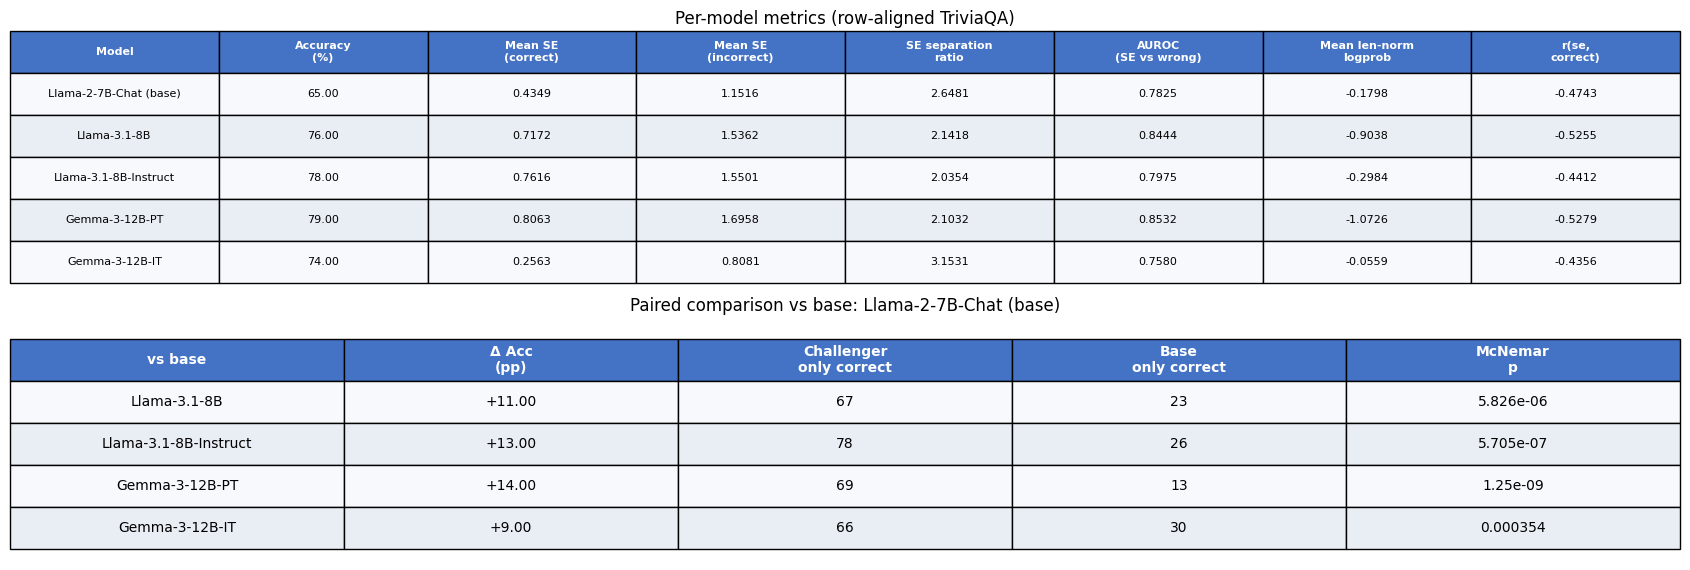

In [12]:
# Requires section 4 executed: names, rows, accuracy, mean_avg_logprob, pearson, mcnemar_paired

base_name = names[0]
b = rows[base_name]
base_acc = accuracy(b)

# Table 1: aligned col_main with the data appended below (8 columns)
col_main = [
    "Model",
    "Accuracy\n(%)",
    "Mean SE\n(correct)",
    "Mean SE\n(incorrect)",
    "SE separation\nratio",
    "AUROC\n(SE vs wrong)",
    "Mean len-norm\nlogprob",
    "r(se,\ncorrect)",
]

rows_main = []
for name in names:
    d = rows[name]
    xs = [r["se_score"] for r in d]
    ys = [1.0 if r["is_correct"] else 0.0 for r in d]
    rsep = se_separation_ratio(d)

    if rsep == float("inf"):
        rsep_s = "inf"
    elif math.isnan(rsep):
        rsep_s = "nan"
    else:
        rsep_s = f"{rsep:.4f}"

    auc = auroc_se_detects_incorrect(d)
    auc_s = f"{auc:.4f}" if not math.isnan(auc) else "nan"

    # Appending exactly 8 items to match col_main
    rows_main.append([
        name,
        f"{accuracy(d) * 100:.2f}",
        f"{mean_se_correct(d):.4f}",
        f"{mean_se_incorrect(d):.4f}",
        rsep_s,
        auc_s,
        f"{mean_avg_logprob(d):.4f}",
        f"{pearson(xs, ys):+.4f}",
    ])

# Table 2: vs baseline
col_vs = [
    "vs base",
    "Δ Acc\n(pp)",
    "Challenger\nonly correct",
    "Base\nonly correct",
    "McNemar\np",
]
rows_vs = []
for name in names[1:]:
    d = rows[name]
    p, n01, n10 = mcnemar_paired(b, d)
    dacc = (accuracy(d) - base_acc) * 100
    rows_vs.append([
        name,
        f"{dacc:+.2f}",
        str(n01),
        str(n10),
        f"{p:.4g}",
    ])

fig, axes = plt.subplots(2, 1, figsize=(17, 5.8))
for ax in axes:
    ax.axis("off")

t0 = axes[0].table(cellText=rows_main, colLabels=col_main, loc="center", cellLoc="center")
t0.scale(1, 2.2)
axes[0].set_title("Per-model metrics (row-aligned TriviaQA)", fontsize=12, pad=12)

t1 = axes[1].table(cellText=rows_vs, colLabels=col_vs, loc="center", cellLoc="center")
t1.scale(1, 2.2)
axes[1].set_title(f"Paired comparison vs base: {base_name}", fontsize=12, pad=12)

for tbl in (t0, t1):
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#4472C4")
            cell.get_text().set_color("white")
            cell.get_text().set_weight("bold")
        else:
            cell.set_facecolor("#E9EDF4" if row % 2 == 0 else "#F7F9FC")

plt.tight_layout()
plt.show()

1. Accuracy (%)
What: Fraction of questions the model answered correctly.
Why here: Establishes the baseline capability of each model. It's the anchor for everything else — you need to know how often a model is right before you can ask whether SE predicts when it's wrong.


2. Mean SE
What: Average semantic entropy score across all questions, regardless of correctness.
Why here: Tells you the overall "uncertainty level" of the model. A lower mean SE means the model is generally more confident/consistent in its outputs. This is important because if mean SE is very low (like Gemma-3-12B-IT at 0.3644), the entire SE range is compressed, which limits its ability to discriminate.


3. Mean SE (correct)
What: Average SE score restricted only to questions the model got right.
Why here: This is the "floor" of your SE signal. Ideally this should be low — correct answers should come from confident, consistent generations. If this is already high, SE is noisy even when the model is right.

4. Mean SE (incorrect)
What: Average SE score restricted only to questions the model got wrong.
Why here: This is the "ceiling" of your SE signal. Ideally this should be high — wrong answers should come from uncertain, divergent generations. This is the core Farquhar hypothesis: hallucinations produce high SE.

5. SE Separation Ratio
What: Mean SE (incorrect) ÷ Mean SE (correct). A ratio > 1 means wrong answers have higher SE than correct ones.
Why here: This is the most direct test of Farquhar's central claim — that SE is systematically higher on hallucinations. It gives you a single number summarizing how well SE directionally separates the two groups. However as your results show, a high ratio alone doesn't guarantee good detection (see Gemma-3-12B-IT).

6. AUROC (SE vs wrong)
What: Area Under the ROC Curve — measures how well SE ranks incorrect answers above correct ones across all possible thresholds. 0.5 = random, 1.0 = perfect.
Why here: This is your primary evaluation metric, directly matching Farquhar et al.'s methodology. Unlike the separation ratio, AUROC accounts for the full distribution of scores, not just the means. It answers the practical question: if you flag the highest-SE questions as likely hallucinations, how often are you right?


7. Mean Length-Normalized Log Probability
What: Average log probability of generated sequences, normalized by length, averaged across the K samples per question.
Why here: This is a baseline comparator to SE. Log probability is a token-level uncertainty measure — the "naive entropy" that Farquhar argued is inferior to SE because it conflates lexical variation with semantic uncertainty. Including it lets you check whether raw probability scores are as useful as SE, or whether SE genuinely adds value beyond what log probs already capture.


8. r(SE, correct) — Point-Biserial Correlation
What: Pearson correlation between SE score and correctness (0/1). A negative value means higher SE associates with incorrect answers.
Why here: Provides a single interpretable correlation coefficient summarizing the SE–correctness relationship. It complements AUROC — AUROC tells you about ranking discrimination, while r tells you about linear association strength. Together they give a fuller picture of how well SE tracks hallucinations.

1. Llama-3.1-8B (Pre-trained, no instruction tuning)
This is the strongest overall performer among the new models. It has the highest AUROC (0.856) of all 5 models including the baseline, and a healthy separation ratio of 2.26. The key reason is that it's a baseline/pre-trained model — like Llama-2-7B, it hasn't been instruction-tuned, so its outputs are naturally more varied and semantically spread when uncertain. It essentially gets the best of both worlds: higher accuracy than the baseline model and SE still works well because the raw pre-training behavior is preserved. This is a really important finding — it suggests the drop in AUROC seen in other models is specifically an instruction-tuning effect, not just a model size or capability effect.




2. Llama-3.1-8B-Instruct (Instruction-tuned)
This is the clearest demonstration of instruction tuning hurting SE. Compare it directly to Llama-3.1-8B. Same base architecture, same parameter count, only difference is instruction tuning — yet AUROC drops by 10.8 points. The SE on correct answers goes up (0.67 → 0.81), meaning the model is more uncertain even when right, while SE on incorrect answers goes down (1.52 → 1.48), meaning it's more confident even when wrong. Instruction tuning essentially blurs the boundary between correct and incorrect in SE space.

3. Gemma-3-12B-PT (Pre-trained, no instruction tuning)
This model tells a similar story to Llama-3.1-8B but even more dramatically. It has the highest accuracy (79.50%) of all 5 models and still maintains strong AUROC (0.849). Notice its mean SE is the highest of all models at 1.0017 — the model generates quite varied outputs overall, but crucially, that variance is much more pronounced on incorrect answers (SE incorrect = 1.70) than correct ones (SE correct = 0.82), giving a clean separation ratio of 2.08. This strongly reinforces the pattern that pre-trained models preserve SE's effectiveness even as they get more capable.


4. Gemma-3-12B-IT (Instruction-tuned)
This is the most extreme case in your dataset and the most analytically interesting. Compare it to its pre-trained counterpart. Three things stand out here. First, instruction tuning dramatically compressed SE — mean SE collapses from 1.00 to 0.36, with everything squeezed toward zero. Second, despite having the highest separation ratio (3.26×), it has the lowest AUROC (0.736). This is the separation ratio vs. AUROC paradox — a 3.26× ratio between two tiny numbers (0.23 and 0.75) creates less absolute spread than a 2.08× ratio between larger numbers (0.82 and 1.70). Third, it's actually less accurate than its pre-trained version (73.75% vs 79.50%), which is unusual and may reflect Gemma-3's instruction tuning being particularly aggressive in ways that hurt factual recall on TriviaQA.

It seems instruction tuning undermines SE effectiveness.

First, recall what SE needs to work
SE works by sampling K responses to the same question and checking if they disagree in meaning. For SE to detect a hallucination, two things must be true:

When the model doesn't know the answer, it must generate semantically diverse outputs
When it does know, it must generate semantically consistent outputs

Instruction tuning attacks both of these.

2. The "Sycophancy" Effect
Instruction-tuned models are trained to be helpful and agreeable. This creates a subtle but important bias: they tend to commit to one answer style and stick with it across samples. Even when the underlying uncertainty is high, the surface-level outputs converge because the model has learned that confident-sounding answers get better human ratings. SE reads this surface convergence as low uncertainty — a false signal.

3. RLHF Specifically Suppresses Output Diversity
The K sampling process that SE relies on requires temperature-based diversity — you sample multiple times at temperature > 0 and hope different meanings emerge. But RLHF shapes the probability distribution of the model such that:

The peak of the distribution (the "preferred" answer style) becomes much sharper
The tails (alternative phrasings, alternative facts) get suppressed

This means even at the same sampling temperature, instruction-tuned models produce less semantic diversity than pre-trained models.

4. Format Consistency Masks Semantic Uncertainty
Instruction-tuned models are trained to follow specific output formats — answer concisely, don't hedge, be direct. This means even semantically uncertain responses get forced into the same syntactic template.

Pre-trained (uncertain):     "Well, it was probably around 1842, or maybe 1843..."
                             "The date is somewhere in the 1840s I believe..."
                             "Historians suggest 1844 or thereabouts..."
→ Multiple semantic clusters → High SE → Detected!

Instruction-tuned (uncertain): "The answer is 1842."
                               "The answer is 1842."
                               "The answer is 1842."
→ One semantic cluster → Low SE → Missed!